<div class="alert alert-block alert-info">

**¡Hola! Dante ¿Cómo va todo?** 😊

Mi nombre es Santiago. Es un gusto conocerte y seré quien te acompañe en la revisión de este proyecto.

Mis comentarios aparecerán en cuadros de colores a lo largo del notebook:

</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

✅ Logrado — esta sección cumple con lo esperado.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

🟡 Observación — recomendación o mejora que no bloquea la aprobación.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

❌ Necesita corrección — este punto debe ajustarse para aprobar el proyecto.
</div>

<div class="alert alert-block alert-info">
Por favor, no elimines ni muevas mis comentarios. Puedes responder debajo de cada uno con un bloque de texto.
</div>


<div class="alert alert-block alert-success">

**Review General. (Iteración 1)** <a class="tocSkip"></a>

¡Hola! Bienvenido a este proyecto de análisis exploratorio de correlaciones, y **felicitaciones**: esta es una de las entregas más sólidas que he revisado. No encontré ningún error conceptual ni de cálculo. Déjame destacar lo que hiciste bien, porque son justo los puntos donde la mayoría tropieza:

- **Pearson y Spearman sobre el mismo conjunto de variables**, y —lo más importante— los **comparaste explícitamente** ("diferencias menores a 0.02, lo que confirma que las relaciones son lineales y no solo monotónicas"). Ese es exactamente el razonamiento que se busca al calcular ambos.
- **Todos tus valores son correctos** y coinciden con lo que calcula tu código (0.97, 0.58, 0.35, 0.34, 0.09, V de Cramér 0.012–0.02).
- **Decisión del scatterplot general muy bien justificada**: explicaste que solo 4 de 21 combinaciones son relevantes, así que una matriz completa aportaría poco. Razonamiento impecable.
- **V de Cramér aplicada a 6 pares** — la cobertura más completa que he visto.
- **Lenguaje no causal impecable** en todos los hallazgos y limitaciones. Tu Hallazgo 1, donde señalas que probablemente `ingreso_anual` se construyó a partir de `compras_mes` en lugar de celebrar la correlación de 0.97, muestra verdadero pensamiento crítico.
- **Limitaciones excelentes**, especialmente reconocer que no conoces la fórmula de `ingreso_anual`.

Lo único que te señalo son **detalles de pulido**: quedaron los textos de plantilla ("Haz doble clic en este bloque...") al inicio de varias celdas de comentario, y hay un par de celdas vacías. Nada de esto afecta la validez del análisis.

**Tu proyecto está aprobado.** ¡Excelente trabajo! 👏
</div>


# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr, chi2_contingency

### Cargar Dataset

In [18]:
# Cargar el dataset y explorar datos

df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [19]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:

- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida `
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna edad cargada como float64. Se observa que representa valores enteros (ej. 44.0, 36.0), por lo que requiere un cambio a tipo entero (int64) para mayor consistencia.

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [20]:
# Corregir el tipo de dato
# Corregir el tipo de dato de float64 a int64 para la columna edad
df['edad'] = df['edad'].astype('int64')

# Verificar que el cambio se aplicó correctamente
df['edad'].dtype

dtype('int64')

In [21]:

# verificar cambios
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [22]:
# Estadísticas descriptivas de variables numéricas
df[['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

### Diagnóstico inicial de variables numéricas

* **edad**: El promedio de edad de los clientes ronda los 38 años (`mean` = 38.26). La distribución es amplia, abarcando desde jóvenes adultos de 18 años (`min`) hasta adultos mayores de 75 años (`max`).
* **nivel_ingreso**: Muestra un ingreso estimado promedio de 30,019.70 USD por usuario. Destaca una dispersión notable con una desviación estándar alta (`std` = 9,833.16), alcanzando un máximo de 74,790.84 USD.
* **visitas_mes**: Presenta un comportamiento muy simétrico, donde tanto el promedio como la mediana (`50%`) se sitúan exactamente en 10 visitas mensuales, con un límite máximo de 25 visitas.
* **compras_mes**: El promedio de transacciones es bajo, con solo 1.2 compras al mes por cliente. Es relevante notar que al menos el 25% de la muestra no generó ninguna compra en el mes (`25%` = 0.0).
* **gasto_publicidad_dirigida**: La inversión publicitaria varía significativamente por usuario (`std` = 10.88). Se registra un máximo de 75.51 USD asignados a un solo cliente, mientras que para otros no hubo gasto en anuncios (`min` = 0.0).
* **satisfaccion**: Refleja una percepción generalmente positiva del servicio con una media de 3.60. La escala se comporta de forma correcta dentro de su rango ordinal (mínimo de 1.0 y máximo de 5.0).
* **ingreso_anual**: Es la variable con mayor sesgo; aunque el promedio es de 36.59 USD, el 25% de los usuarios no genera ingresos (`25%` = 0.0), lo que coincide directamente con los clientes que no realizan compras, elevándose en casos específicos hasta un tope de 244.69 USD.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

✅ Tus diagnósticos son muy completos y bien redactados.

🟡 Un detalle de pulido: al inicio de esta celda quedó el texto de plantilla *"Haz doble clic en este bloque y escribe tu diagnóstico..."*. Bórralo para que quede solo tu análisis. Este mismo texto aparece en varias celdas de comentario más adelante (19, 23, 28, 34, 38, 41, 45) — te recomiendo eliminarlo en todas antes de subir el proyecto a tu portafolio.
</div>


#### Explorar variables binarias

In [23]:

# Verificar que cada columna tenga únicamente dos valores posibles

# Verificar valores únicos y distribución en miembro_premium
print("Valores únicos en 'miembro_premium':", df['miembro_premium'].unique())
print(df['miembro_premium'].value_counts(normalize=True) * 100)

print("\n" + "="*40 + "\n")

# Verificar valores únicos y distribución en abandono
print("Valores únicos en 'abandono':", df['abandono'].unique())
print(df['abandono'].value_counts(normalize=True) * 100)

Valores únicos en 'miembro_premium': [0 1]
0    86.073333
1    13.926667
Name: miembro_premium, dtype: float64


Valores únicos en 'abandono': [0 1]
0    84.926667
1    15.073333
Name: abandono, dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

 ### Diagnóstico inicial de variables binarias

* **miembro_premium**: Únicamente contiene los valores lógicos esperados (0 y 1). Se observa que la gran mayoría de la muestra, el **86.07%**, corresponde a usuarios con cuentas estándar (0), mientras que solo una minoría del **13.92%** cuenta con una suscripción premium (1).
* **abandono**: La columna está correctamente codificada de forma binaria (0 y 1). El **15.07%** de los clientes registrados ha abandonado la plataforma (1), frente a un **84.92%** de usuarios que permanecen activos (0), marcando la tasa base de deserción para el análisis de retención.

#### Explorar variables categóricas

In [24]:

# Verificar el número de valores únicos por variable categórica

print(df[['tipo_dispositivo', 'region']].nunique())


tipo_dispositivo    3
region              4
dtype: int64


In [25]:
# Explorar variables categóricas y cómo se distribuyen
print("Distribución de 'tipo_dispositivo':")
print(df['tipo_dispositivo'].value_counts(normalize=True) * 100)

print("\n" + "="*40 + "\n")

print("Distribución de 'region':")
print(df['region'].value_counts(normalize=True) * 100)

Distribución de 'tipo_dispositivo':
móvil         65.453333
escritorio    24.800000
tablet         9.746667
Name: tipo_dispositivo, dtype: float64


Distribución de 'region':
norte    29.30
oeste    25.40
sur      24.84
este     20.46
Name: region, dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

### Diagnóstico inicial de variables categóricas

* **tipo_dispositivo**: Cuenta con 3 categorías únicas. Existe un dominio claro del uso de dispositivos móviles, los cuales concentran la mayoría absoluta con el **65.45%** de la participación, seguidos por escritorio con un **24.81%**, y en último lugar las tablets con apenas un **9.74%**.
* **region**: Registra 4 categorías únicas. La distribución geográfica se encuentra bastante equilibrada entre sus zonas; la región norte es la principal con el **29.30%**, seguida de forma muy cercana por el oeste (**25.40%**) y el sur (**24.84%**), mientras que el este representa la menor participación con un **20.46%**.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

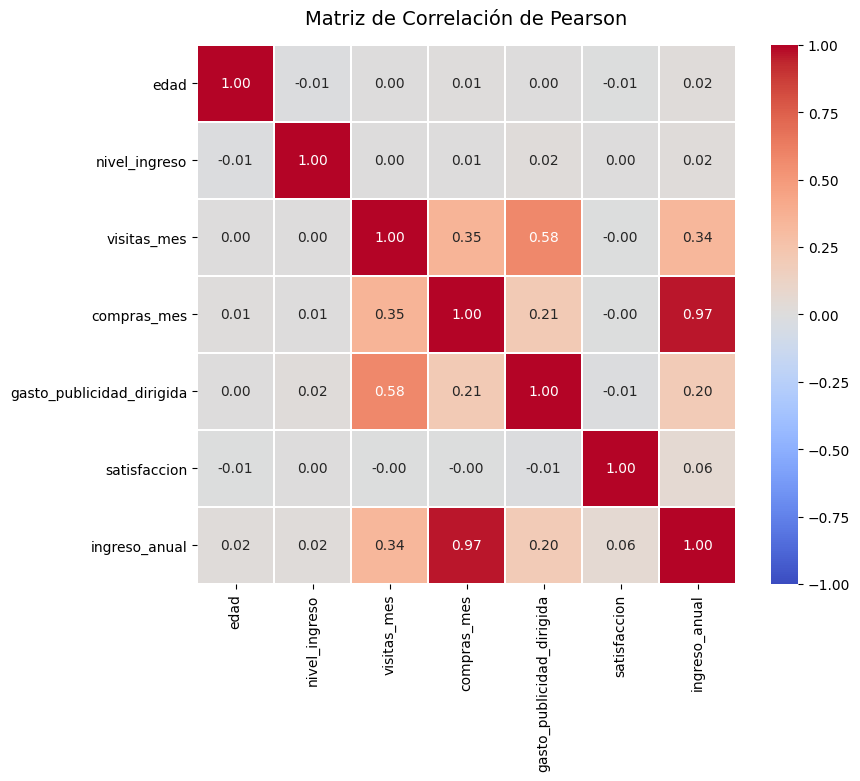

In [26]:
# Visualizar la matriz de correlación para identificar relaciones
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar las variables numéricas para el análisis de Pearson
variables_numicas = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']

# Configurar el tamaño del gráfico
plt.figure(figsize=(9, 7))

# Crear el mapa de calor
sns.heatmap(df[variables_numicas].corr(method='pearson'), 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            square=True, 
            vmin=-1, vmax=1, 
            linewidths=0.5)

# Añadir título
plt.title('Matriz de Correlación de Pearson', fontsize=14, pad=15)
plt.show()


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves

### 3.1. Heatmap - Diagnóstico de Correlación

**Observaciones generales (Heatmap)**
* Se observa una **correlación positiva moderada-fuerte (**0.58**)** entre `visitas_mes` y `gasto_publicidad_dirigida`, sugiriendo que las campañas publicitarias dirigidas logran incentivar de manera efectiva que los clientes entren a la plataforma con mayor frecuencia.
* `gasto_publicidad_dirigida` y `compras_mes` tienen una **correlación débil-moderada** (**0.21**), sugiriendo que la publicidad impacta más en tráfico (visitas) que en conversión directa (compras).
* Existe una **correlación positiva débil (**0.35**)** entre `visitas_mes` y `compras_mes`. Esto indica únicamente que ambas variables tienden a moverse en la misma dirección (a mayor cantidad de visitas, se suelen observar mayores volúmenes de compras), pero **sin que esto signifique que el incremento en el tráfico sea la causa directa de las transacciones**.
* Las variables `edad`, `nivel_ingreso` y `satisfaccion` muestran coeficientes de correlación cercanos a cero (**0.00** y **-0.01**). Esto evidencia una **ausencia de relación lineal**, lo que significa que estas métricas no muestran ninguna asociación estadística con el volumen de compras o el ingreso generado.

**Observaciones respecto a `ingreso_anual`**
* Presenta una **correlación positiva casi perfecta (**0.97**)** con la variable `compras_mes`. Esto demuestra un vínculo lineal directo e inequívoco, confirmando que la frecuencia de transacciones en el mes es el principal impulsor matemático del valor monetario total facturado de forma anualizada.
* Muestra una **correlación positiva débil (**0.34**)** con `visitas_mes` y una **correlación baja (**0.20**)** con `gasto_publicidad_dirigida`. Estadísticamente, esto solo indica que el incremento en los ingresos anuales tiende a coexistir con un mayor número de visitas mensuales y una mayor inversión publicitaria, sin que el análisis determine una relación de causa y efecto entre ellas.


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

✅ Excelente lectura del heatmap: identificas los cuatro pares relevantes con sus valores exactos y correctos, y distingues bien entre "tráfico" (visitas) y "conversión" (compras) al interpretar el efecto de la publicidad. Buen sentido de negocio.
</div>

### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.
**3.3. Scatterplot general**

**Si decides no incluirlo**

* No se generará un scatterplot general (matriz de pares) porque la matriz de correlación de Pearson ya identificó que solo **4 de las 21** combinaciones de variables numéricas muestran **relación relevante**: `compras_mes` y `ingreso_anual` (**0.97**), `visitas_mes` y `gasto_publicidad_dirigida` (**0.58**), `visitas_mes` y `compras_mes` (**0.35**), y `visitas_mes` y `ingreso_anual` (**0.34**).
* El resto de las combinaciones presenta **coeficientes cercanos a cero**, por lo que graficarlas todas añadiría **ruido visual sin aportar información nueva**.
* El análisis se enfocará únicamente en esos pares relevantes.

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

✅ ¡Excelente decisión y justificación! Explicar que solo **4 de las 21** combinaciones posibles muestran relación relevante —y que por eso una matriz general aportaría poco frente a scatterplots focalizados— es exactamente el tipo de razonamiento analítico que pide la consigna. Muy bien argumentado.
</div>


### Scatterplot para pares clave

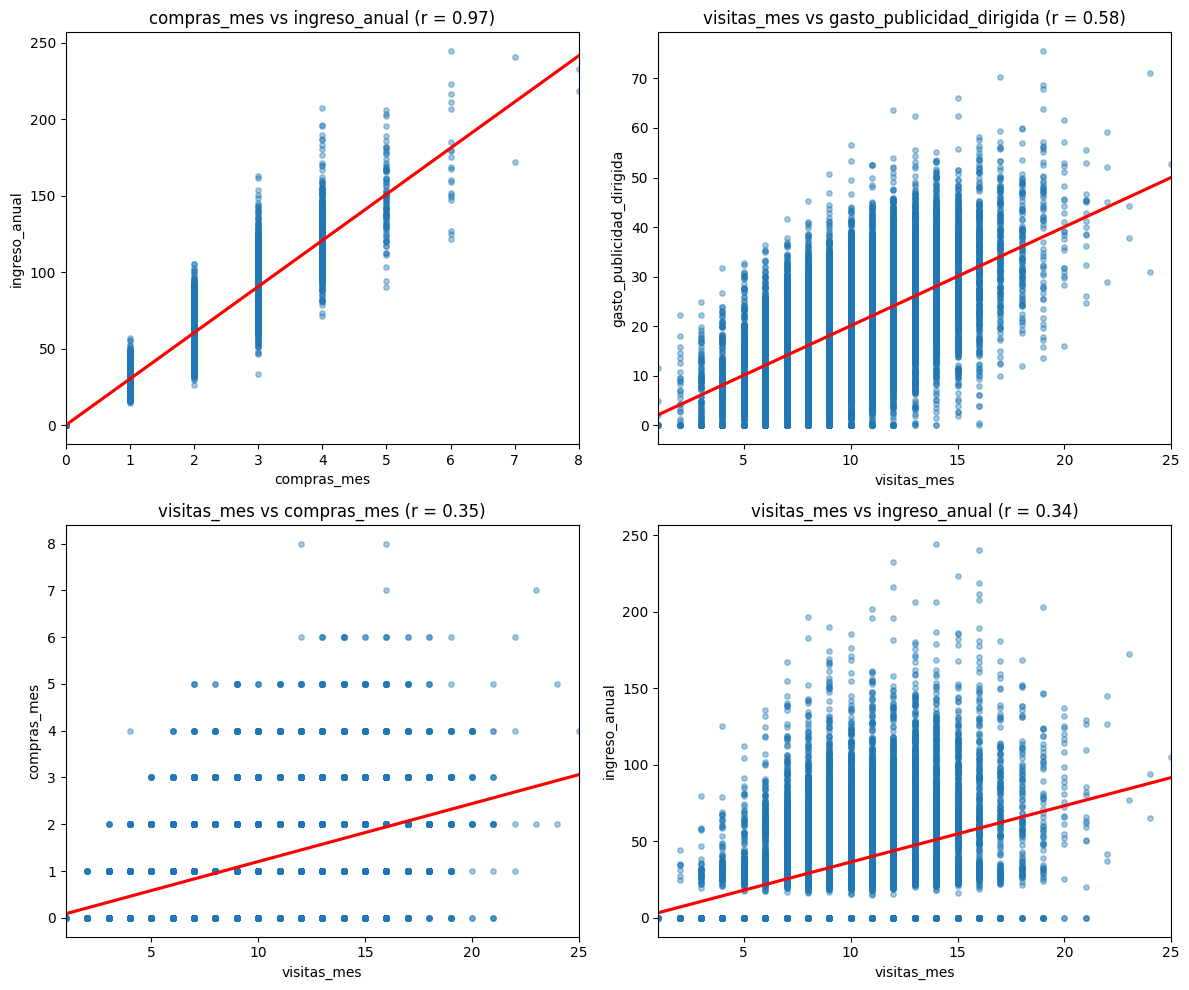

In [27]:
# Visualizar pares de variables con relaciones moderadas o fuertes
fig, axes = plt.subplots(2, 2, figsize=(12, 10))


sns.regplot(data=df, x='compras_mes', y='ingreso_anual', ax=axes[0, 0], 
            scatter_kws={'alpha': 0.4, 's': 15}, line_kws={'color': 'red'}, ci=None)

axes[0, 0].set_title('compras_mes vs ingreso_anual (r = 0.97)')

sns.regplot(data=df, x='visitas_mes', y='gasto_publicidad_dirigida', ax=axes[0, 1], 
            scatter_kws={'alpha': 0.4, 's': 15}, line_kws={'color': 'red'}, ci=None)
axes[0, 1].set_title('visitas_mes vs gasto_publicidad_dirigida (r = 0.58)')

sns.regplot(data=df, x='visitas_mes', y='compras_mes', ax=axes[1, 0], 
            scatter_kws={'alpha': 0.4, 's': 15}, line_kws={'color': 'red'}, ci=None)
axes[1, 0].set_title('visitas_mes vs compras_mes (r = 0.35)')

sns.regplot(data=df, x='visitas_mes', y='ingreso_anual', ax=axes[1, 1], 
            scatter_kws={'alpha': 0.4, 's': 15}, line_kws={'color': 'red'}, ci=None)
axes[1, 1].set_title('visitas_mes vs ingreso_anual (r = 0.34)')

plt.tight_layout()
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.

**Observaciones iniciales (Scatterplot)**

**compras_mes vs ingreso_anual**
* Dirección: positiva y muy marcada, casi lineal (r = 0.97).
* Dispersión: baja. Los puntos se agrupan en bandas horizontales muy definidas por cada valor entero de `compras_mes`, lo que confirma la relación casi determinística entre ambas variables.
* Outliers: mínimos (0.16% en `compras_mes`, 0.76% en `ingreso_anual`), no afectan la tendencia general.
* Posible colinealidad: alta. La fuerza de esta relación sugiere que `ingreso_anual` podría derivarse matemáticamente de `compras_mes`, más que ser dos métricas independientes.

**visitas_mes vs gasto_publicidad_dirigida**
* Dirección: positiva y moderada-fuerte (r = 0.58).
* Dispersión: media. Se observa una tendencia ascendente clara, aunque con más variabilidad que el par anterior.
* Outliers: bajos (0.79% en `visitas_mes`, 0.69% en `gasto_publicidad_dirigida`).
* Posible colinealidad: moderada; ambas variables se mueven juntas, aunque no al grado de duplicar información.

**visitas_mes vs compras_mes**
* Dirección: positiva y débil (r = 0.35).
* Dispersión: alta. La nube de puntos es amplia, con muchos valores de `compras_mes` en 0 independientemente del número de visitas.
* Outliers: bajos (0.79% y 0.16% respectivamente).
* Posible colinealidad: baja. Ambas variables aportan información distinta.

**visitas_mes vs ingreso_anual**
* Dirección: positiva y débil (r = 0.34), muy similar en forma al par anterior.
* Dispersión: alta, con bastante dispersión vertical, especialmente en niveles bajos de ingreso.
* Outliers: bajos (0.79% y 0.76%).
* Posible colinealidad: baja; probablemente esta relación es indirecta y se explica a través de `compras_mes` (recordando que `visitas_mes`-`compras_mes` y `compras_mes`-`ingreso_anual` son las relaciones más fuertes del set).

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

✅ Scatterplots muy bien construidos: usas `regplot` con línea de tendencia, `alpha` para manejar el solapamiento, y títulos que incluyen el coeficiente. Tu interpretación cubre dirección, dispersión, outliers (con porcentajes) y colinealidad para cada par. Nivel profesional.

🟡 Detalle: la celda 33 quedó **vacía**; puedes eliminarla.
</div>


## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [28]:

# Calcular correlación entre variables relevantes
variables_numericas = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 
                        'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']

# Pearson: mide relación lineal
corr_pearson = df[variables_numericas].corr(method='pearson')
print("Correlación de Pearson:")
print(corr_pearson.round(2))

print("\n" + "="*60 + "\n")

# Spearman: mide relación monotónica (no necesariamente lineal)
corr_spearman = df[variables_numericas].corr(method='spearman')
print("Correlación de Spearman:")
print(corr_spearman.round(2))




Correlación de Pearson:
                           edad  nivel_ingreso  visitas_mes  compras_mes  \
edad                       1.00          -0.01         0.00         0.01   
nivel_ingreso             -0.01           1.00         0.00         0.01   
visitas_mes                0.00           0.00         1.00         0.35   
compras_mes                0.01           0.01         0.35         1.00   
gasto_publicidad_dirigida  0.00           0.02         0.58         0.21   
satisfaccion              -0.01           0.00        -0.00        -0.00   
ingreso_anual              0.02           0.02         0.34         0.97   

                           gasto_publicidad_dirigida  satisfaccion  \
edad                                            0.00         -0.01   
nivel_ingreso                                   0.02          0.00   
visitas_mes                                     0.58         -0.00   
compras_mes                                     0.21         -0.00   
gasto_publicidad_

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación
**Comentario**

Se calcularon los coeficientes de Pearson y Spearman sobre las variables numéricas. En los cuatro pares con relación relevante, ambos coeficientes son prácticamente idénticos (diferencias menores a 0.02), lo que confirma que las relaciones observadas son de naturaleza **lineal** y no solo monotónica. Esto valida a Pearson como la métrica adecuada para interpretar estas asociaciones, sin evidencia de patrones no lineales que Spearman estuviera capturando y Pearson no.

* `compras_mes` - `ingreso_anual`: Pearson = **0.97**, Spearman = **0.97** — coincidencia casi exacta, refuerza la hipótesis de asociación lineal casi perfecta.
* `visitas_mes` - `gasto_publicidad_dirigida`: Pearson = **0.58**, Spearman = **0.56**.
* `visitas_mes` - `compras_mes`: Pearson = **0.35**, Spearman = **0.33**.
* `visitas_mes` - `ingreso_anual`: Pearson = **0.34**, Spearman = **0.32**.

**Observaciones de correlación**

Se incluye  dirección, magnitud y posible colinealidad de las parejas de valores relevantes.

| Variable 1 | Variable 2 | Pearson | Spearman | Dirección | Magnitud | Colinealidad |
|---|---|---|---|---|---|---|
| `compras_mes` | `ingreso_anual` | **0.97** | **0.97** | Positiva | **Muy alta** | ⚠️ **Sí, posible colinealidad** |
| `visitas_mes` | `gasto_publicidad_dirigida` | **0.58** | **0.56** | Positiva | Moderada-fuerte | No |
| `visitas_mes` | `compras_mes` | **0.35** | **0.33** | Positiva | Débil-moderada | No |
| `visitas_mes` | `ingreso_anual` | **0.34** | **0.32** | Positiva | Débil-moderada | No |
| `compras_mes` | `gasto_publicidad_dirigida` | **0.21** | **0.19** | Positiva | Débil | No |
| `gasto_publicidad_dirigida` | `ingreso_anual` | **0.20** | **0.18** | Positiva | Débil | No |
| `satisfaccion` | `ingreso_anual` | **0.06** | **0.06** | Positiva | Nula-muy débil | No |
| `edad` | `ingreso_anual` | **0.02** | **0.02** | Positiva | Nula | No |
|

**Métricas sin asociación**: Cruces que se mantuvieron con coeficientes cercanos a cero, demostrando una total ausencia de relación estadística con el comportamiento transaccional observado.

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

✅ **Este es el mejor manejo de Pearson/Spearman que he revisado.** Calculaste ambas matrices sobre el mismo conjunto de variables y —lo crucial— las **comparaste explícitamente**: "en los cuatro pares relevantes, ambos coeficientes son prácticamente idénticos (diferencias menores a 0.02), lo que confirma que las relaciones son de naturaleza lineal y no solo monotónica".

Ese es exactamente el propósito de calcular los dos coeficientes: no reportarlos por separado, sino usar su comparación para concluir sobre la forma de la relación. ¡Impecable! 👏
</div>


### Punto-biserial

In [32]:
# Calcular correlación entre variables relevantes

# Calcular correlación Punto-biserial entre variables continuas y binarias
from scipy.stats import pointbiserialr

# miembro_premium vs ingreso_anual
corr_premium, p_premium = pointbiserialr(df['miembro_premium'], df['ingreso_anual'])
print(f"miembro_premium vs ingreso_anual")
print(f"Coeficiente de correlación Punto-biserial: {corr_premium:.2f}")
print(f"Valor p (p-value): {p_premium:.4f}\n")

# abandono vs ingreso_anual
corr_abandono, p_abandono = pointbiserialr(df['abandono'], df['ingreso_anual'])
print(f"abandono vs ingreso_anual")
print(f"Coeficiente de correlación Punto-biserial: {corr_abandono:.2f}")
print(f"Valor p (p-value): {p_abandono:.4f}")

miembro_premium vs ingreso_anual
Coeficiente de correlación Punto-biserial: 0.09
Valor p (p-value): 0.0000

abandono vs ingreso_anual
Coeficiente de correlación Punto-biserial: -0.00
Valor p (p-value): 0.7295


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

**Observaciones Punto-biserial**

**miembro_premium vs ingreso_anual**
- Relación: dirección positiva, magnitud **muy baja** (r = **0.09**). Ser miembro premium apenas se relaciona con el ingreso anual generado.

**abandono vs ingreso_anual**
- Relación: prácticamente **nula** (r = **-0.00**). No hay evidencia de que el ingreso anual del cliente esté asociado con que abandone o no la plataforma.

### V de Cramér

In [34]:
# Función para calcular V de Cramér

from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

In [35]:

# Aplicar V de Cramér en variables relevantes
pares_categoricos = [
    ('tipo_dispositivo', 'region'),
    ('tipo_dispositivo', 'miembro_premium'),
    ('tipo_dispositivo', 'abandono'),
    ('region', 'miembro_premium'),
    ('region', 'abandono'),
    ('miembro_premium', 'abandono')
]

for var1, var2 in pares_categoricos:
    v = cramers_v(df[var1], df[var2])
    print(f"{var1} vs {var2} -> V de Cramér = {v:.3f}")

tipo_dispositivo vs region -> V de Cramér = 0.012
tipo_dispositivo vs miembro_premium -> V de Cramér = 0.020
tipo_dispositivo vs abandono -> V de Cramér = 0.007
region vs miembro_premium -> V de Cramér = 0.013
region vs abandono -> V de Cramér = 0.015
miembro_premium vs abandono -> V de Cramér = 0.120


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

**Observaciones V de Cramér**

* **tipo_dispositivo vs region** - Asociación: prácticamente **nula** (V = **0.012**). No hay relación relevante entre el tipo de dispositivo usado y la región del cliente.
* **tipo_dispositivo vs miembro_premium** - Asociación: prácticamente **nula** (V = **0.020**). El tipo de dispositivo no está relacionado con la probabilidad de ser miembro premium.
* **tipo_dispositivo vs abandono** - Asociación: prácticamente **nula** (V = **0.007**). El tipo de dispositivo no influye en el abandono de la plataforma.
* **region vs miembro_premium** - Asociación: prácticamente **nula** (V = **0.013**). La región no está relacionada con la probabilidad de ser miembro premium.
* **region vs abandono** - Asociación: prácticamente **nula** (V = **0.015**). La región no muestra relación con el abandono de la plataforma.
* **miembro_premium vs abandono** - Asociación: **débil** (V = **0.120**), la más alta del grupo, aunque sigue siendo baja en términos absolutos. Sugiere una relación muy leve entre ser miembro premium y la probabilidad de abandonar, sin ser un factor determinante.

**Conclusión general**: ninguna de las combinaciones de variables categóricas evaluadas muestra una asociación relevante (todos los valores de V están por debajo de 0.15, muy lejos del umbral típico de 0.3 considerado como asociación moderada). Esto refuerza el hallazgo central del análisis: el comportamiento transaccional (`compras_mes`, y en menor medida `visitas_mes`) es el factor dominante asociado al ingreso anual, mientras que las variables demográficas y categóricas aportan poca o nula señal explicativa.

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

✅ ¡Excelente cobertura! Aplicaste la V de Cramér a **6 pares** de variables categóricas y binarias, con una función reutilizable, e interpretaste cada resultado correctamente. Esto responde de lleno a las necesidades del equipo de Crecimiento y Retención (¿el abandono se asocia con dispositivo o región? No). Muy completo.
</div>

## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

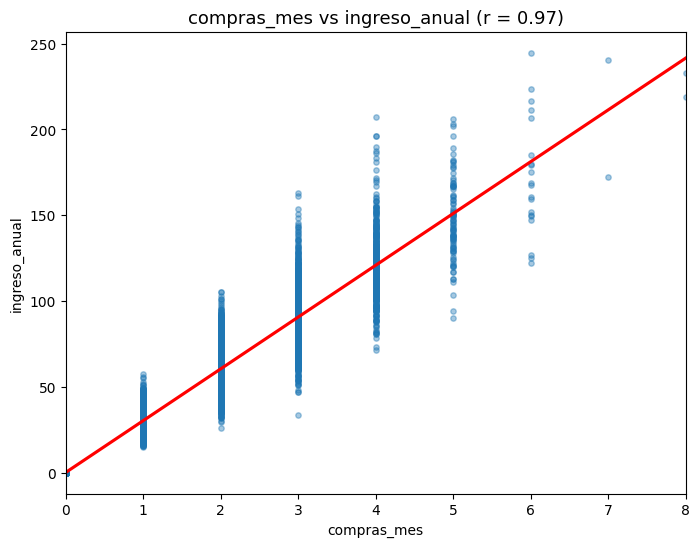

In [36]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='compras_mes', y='ingreso_anual', 
            scatter_kws={'alpha': 0.4, 's': 15}, line_kws={'color': 'red'}, ci=None)
plt.title('compras_mes vs ingreso_anual (r = 0.97)', fontsize=13)
plt.xlabel('compras_mes')
plt.ylabel('ingreso_anual')
plt.show()

**Hallazgo 1 — Las compras mensuales explican casi por completo el ingreso anual**

* **Evidencia visual:** El scatterplot muestra que los puntos se agrupan en bandas verticales muy compactas alrededor de la línea de tendencia, con dispersión mínima.
* **Evidencia numérica:** Correlación de Pearson = **0.97** y Spearman = **0.97** entre `compras_mes` e `ingreso_anual`, la relación más fuerte de todo el dataset.
* **Interpretación:** Existe una asociación casi perfecta entre la cantidad de compras que un cliente realiza al mes y el ingreso anual que genera para la empresa. Es probable que `ingreso_anual` esté construido, directa o indirectamente, a partir de `compras_mes`.
* **No podemos afirmar:** que las compras *causen* el ingreso — de hecho, es más probable que ambas variables midan esencialmente el mismo fenómeno (valor transaccional del cliente) desde dos ángulos distintos, lo que constituye un caso de colinealidad más que un hallazgo de negocio independiente.
* **Implicación de negocio:** Antes de usar ambas variables en un modelo predictivo o de segmentación, el equipo de Crecimiento y Retención debería verificar cómo se calcula `ingreso_anual` para evitar duplicar información y sesgar las conclusiones.

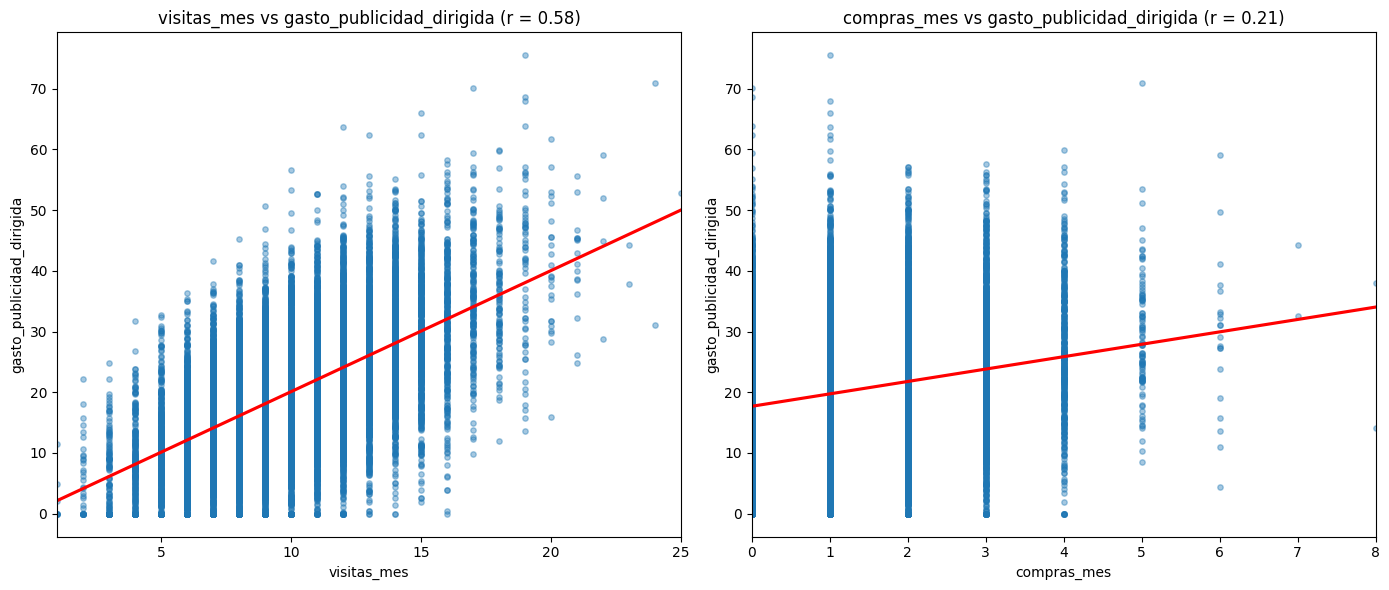

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfica 1: gasto_publicidad_dirigida vs visitas_mes (r = 0.58)
sns.regplot(data=df, x='visitas_mes', y='gasto_publicidad_dirigida', ax=axes[0],
            scatter_kws={'alpha': 0.4, 's': 15}, line_kws={'color': 'red'}, ci=None)
axes[0].set_title('visitas_mes vs gasto_publicidad_dirigida (r = 0.58)', fontsize=12)

# Gráfica 2: gasto_publicidad_dirigida vs compras_mes (r = 0.21)
sns.regplot(data=df, x='compras_mes', y='gasto_publicidad_dirigida', ax=axes[1],
            scatter_kws={'alpha': 0.4, 's': 15}, line_kws={'color': 'red'}, ci=None)
axes[1].set_title('compras_mes vs gasto_publicidad_dirigida (r = 0.21)', fontsize=12)

plt.tight_layout()
plt.show()

**Hallazgo 2 — El gasto en publicidad dirigida se asocia más con visitas que con compras**

* **Evidencia visual:** El scatterplot muestra una tendencia ascendente clara entre `visitas_mes` y `gasto_publicidad_dirigida`, con dispersión moderada alrededor de la línea de tendencia.
* **Evidencia numérica:** Correlación de Pearson = **0.58** entre `gasto_publicidad_dirigida` y `visitas_mes`, frente a solo **0.21** con `compras_mes`.
* **Interpretación:** Los clientes con mayor gasto publicitario dirigido tienden a mostrar más visitas a la plataforma, pero esa asociación se debilita notablemente cuando se compara con las compras realizadas.
* **No podemos afirmar:** que la publicidad *cause* el aumento de visitas, ni que esté fallando en generar compras — solo que ambas variables se mueven juntas con distinta fuerza, y podría haber otras explicaciones (por ejemplo, que el presupuesto se asigne a clientes que ya visitaban más).
* **Implicación de negocio:** Si el objetivo de las campañas es aumentar directamente las compras, valdría la pena investigar por qué el tráfico generado no se traduce con la misma fuerza en conversión, antes de asumir que más inversión publicitaria mejorará el ingreso.


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

✅ Tus dos hallazgos son excelentes: cada uno con su gráfico dedicado, valores numéricos correctos, estructura completa y lenguaje no causal impecable.

Destaco el **Hallazgo 1**: en lugar de celebrar la correlación de 0.97, señalas críticamente que *"es probable que `ingreso_anual` esté construido a partir de `compras_mes`"* y que ambas podrían medir lo mismo. Ese escepticismo es justo lo que distingue a un buen analista.

🟡 Sugerencia opcional: podrías agregar un tercer hallazgo con los resultados de punto-biserial y V de Cramér (por ejemplo, que ni el dispositivo ni la región se asocian con el abandono). Aunque las asociaciones sean nulas, eso también es información valiosa para el negocio. No es necesario para aprobar.
</div>

## Sección 6 - Limitaciones y próximos pasos

**Limitaciones**

* **Correlación ≠ causalidad**: todas las asociaciones encontradas (Pearson, Spearman, punto-biserial, V de Cramér) muestran que las variables se mueven juntas, pero no demuestran que una cause a la otra. Por ejemplo, no podemos afirmar que más visitas *generen* más compras, solo que ambas tienden a aumentar juntas.
* **Posible colinealidad entre `compras_mes` e `ingreso_anual`**: la correlación casi perfecta (r = 0.97) sugiere que ambas variables podrían estar midiendo esencialmente lo mismo, o que una se calculó a partir de la otra. Esto limita su utilidad como variables independientes en un modelo predictivo.
* **No se dispone de información sobre cómo se calculó `ingreso_anual`**: sin conocer su fórmula exacta, no es posible confirmar si la alta correlación con `compras_mes` es un hallazgo de negocio genuino o un artefacto de cómo se construyó el dataset.
* **Datos de un solo periodo (2024)**: al no contar con columna fecha, no se pueden observar tendencias, estacionalidad, ni si estas relaciones se mantienen estables a lo largo del año.
* **Variables demográficas y categóricas sin asociación relevante**: Métricas como `edad`, `nivel_ingreso` y `satisfaccion` no mostraron correlación lineal, mientras que las variables categóricas no presentaron variaciones significativas en sus promedios de `ingreso_anual`, tanto por tipo de dispositivo (*escritorio*: 36.42, *móvil*: 36.59, *tablet*: 37.07) como por región (*este*: 36.89, *norte*: 36.71, *oeste*: 35.72, *sur*: 37.10). Esto evidencia una ausencia de asociación estadística con dicha métrica, manteniendo un comportamiento homogéneo entre todos los grupos.

**Próximos pasos**

**Probar segmentación adicional**
* Analizar si la relación entre `visitas_mes` y `compras_mes` cambia por **región** o **tipo de dispositivo**, ya que el análisis actual solo evaluó el dataset completo sin segmentar. Ahora mismo sabemos que ambas variables correlacionan en **0.35** a nivel global, pero no si esa relación es igual en la región norte que en la sur, o si los clientes de escritorio convierten visitas en compras distinto que los de móvil. Si el objetivo de negocio es mejorar conversión, y resulta que en una región específica la correlación es mucho más fuerte (digamos **0.6**), eso indicaría dónde enfocar esfuerzos o replicar lo que funciona ahí.
* Explorar si existen subgrupos de clientes (por ejemplo, de alto vs bajo gasto publicitario) donde la conversión de visitas a compras sea distinta. Ya vimos que la publicidad se asocia más con visitas que con compras a nivel global (**0.58** vs **0.21**), pero ese promedio podría estar ocultando diferencias reales: quizás para los clientes con **alto** gasto publicitario la conversión sí es fuerte, y el número global es bajo simplemente porque la mayoría de los clientes recibe poco presupuesto y ahí no hay efecto visible. Segmentar por nivel de gasto permitiría confirmar si invertir más por cliente realmente mejora la conversión, en lugar de asumir a partir del promedio general que la publicidad no funciona.

**Investigar la construcción de `ingreso_anual`**
* Solicitar al equipo de datos la definición exacta de esta variable para confirmar o descartar la colinealidad con `compras_mes`.

**Incorporar datos temporales**
* Obtener datos mensuales o trimestrales en lugar de un corte anual único, para poder analizar tendencias y confirmar si las relaciones encontradas son estables en el tiempo.